In [1]:
import torch
import torch.nn.functional as F
import torch_geometric

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet
from torch_geometric.transforms import BaseTransform
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device       : {device}")
print(f"PyTorch version    : {torch.__version__}")
print(f"PyG version        : {torch_geometric.__version__}")
print(f"NumPy version      : {np.__version__}")

Using device       : cuda
PyTorch version    : 2.3.1+cu118
PyG version        : 2.7.0
NumPy version      : 1.26.4


In [2]:
from torch_geometric.transforms import BaseTransform

class CastToFloat(BaseTransform):
    def forward(self, data):
        data.x = data.x.to(torch.float32)
        if hasattr(data, 'edge_attr') and data.edge_attr is not None:
            data.edge_attr = data.edge_attr.to(torch.float32)
        return data

# ────────────────────────────────────────────────────────────────
# Load dataset (delete ./data/MoleculeNet/processed/ folder first time 
# if you still see int64 dtype after this change)
dataset = MoleculeNet(
    root='./data/MoleculeNet',
    name='ESOL',
    transform=CastToFloat()
)

print(f"Dataset            : ESOL (MoleculeNet)")
print(f"Number of graphs   : {len(dataset):,}")
print(f"Node features dim  : {dataset.num_node_features}")
print(f"Target shape       : {dataset[0].y.shape}")
print(f"Example target     : {dataset[0].y}")
print(f"edge_index dtype   : {dataset[0].edge_index.dtype}")
print(f"x dtype            : {dataset[0].x.dtype}")   # ← should now be torch.float32

Dataset            : ESOL (MoleculeNet)
Number of graphs   : 1,128
Node features dim  : 9
Target shape       : torch.Size([1, 1])
Example target     : tensor([[-0.7700]])
edge_index dtype   : torch.int64
x dtype            : torch.float32


In [3]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

train_idx, test_idx = train_test_split(
    range(len(dataset)),
    test_size=0.20,
    random_state=42
)

train_loader = DataLoader(
    dataset[train_idx],
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset[test_idx],
    batch_size=32,
    shuffle=False
)

print(f"Train molecules    : {len(train_loader.dataset):4d}")
print(f"Test  molecules    : {len(test_loader.dataset):4d}")

Train molecules    :  902
Test  molecules    :  226


In [14]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class SimpleGCN(torch.nn.Module):
    def __init__(self, hidden_channels=64):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = torch.nn.Linear(hidden_channels, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.15, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.15, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # Graph-level readout
        x = global_mean_pool(x, batch)          # → [num_graphs, hidden_channels]
        x = self.lin(x)                         # → [num_graphs, 1]
        return x

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SimpleGCN(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

print(f"Model initialized on device: {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized on device: cuda
Number of parameters: 9,025


In [16]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds = []
    truths = []
    
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)                    # shape: [batch_size, 1]
        preds.append(out.cpu().numpy())
        truths.append(batch.y.cpu().numpy())
    
    preds  = np.concatenate(preds).ravel()
    truths = np.concatenate(truths).ravel()
    
    rmse = np.sqrt(mean_squared_error(truths, preds))
    return rmse

In [17]:
def train_one_epoch():
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)                    # [num_graphs_in_batch, 1]
        loss = criterion(out.squeeze(-1), batch.y.squeeze(-1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

    return total_loss / total_graphs

In [18]:
import numpy as np

print("Starting training...\n")

best_test_rmse = float('inf')
best_epoch = 0

for epoch in range(1, 81):
    train_loss = train_one_epoch()
    
    train_rmse = evaluate(train_loader)
    test_rmse  = evaluate(test_loader)
    
    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        best_epoch = epoch
        torch.save(model.state_dict(), "best_esol_gcn.pt")
        print(f"  → New best Test RMSE: {test_rmse:.4f}  (epoch {epoch})")
    
    if epoch <= 10 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | loss {train_loss:8.4f} | "
              f"train RMSE {train_rmse:.4f} | test RMSE {test_rmse:.4f}")

print("\n" + "═"*70)
print(f"Training finished after 80 epochs")
print(f"Best test RMSE : {best_test_rmse:.4f}  (epoch {best_epoch})")
print("Best model saved → best_esol_gcn.pt")

Starting training...

  → New best Test RMSE: 2.1572  (epoch 1)
Epoch   1 | loss   5.2490 | train RMSE 2.0670 | test RMSE 2.1572
  → New best Test RMSE: 2.0663  (epoch 2)
Epoch   2 | loss   4.1500 | train RMSE 1.9757 | test RMSE 2.0663
Epoch   3 | loss   3.9318 | train RMSE 2.1697 | test RMSE 2.2354
  → New best Test RMSE: 2.0606  (epoch 4)
Epoch   4 | loss   4.2325 | train RMSE 1.9747 | test RMSE 2.0606
  → New best Test RMSE: 2.0528  (epoch 5)
Epoch   5 | loss   3.8813 | train RMSE 1.9597 | test RMSE 2.0528
Epoch   6 | loss   3.8644 | train RMSE 1.9736 | test RMSE 2.0727
  → New best Test RMSE: 2.0464  (epoch 7)
Epoch   7 | loss   3.9927 | train RMSE 1.9627 | test RMSE 2.0464
  → New best Test RMSE: 1.9950  (epoch 8)
Epoch   8 | loss   3.6813 | train RMSE 1.8925 | test RMSE 1.9950
Epoch   9 | loss   3.5789 | train RMSE 1.9120 | test RMSE 2.0246
  → New best Test RMSE: 1.9087  (epoch 10)
Epoch  10 | loss   3.4151 | train RMSE 1.7876 | test RMSE 1.9087
  → New best Test RMSE: 1.8988  (

In [4]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_add_pool

class BetterGCN(torch.nn.Module):
    def __init__(self, hidden_channels=128):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.bn1   = torch.nn.BatchNorm1d(hidden_channels)
        
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2   = torch.nn.BatchNorm1d(hidden_channels)
        
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3   = torch.nn.BatchNorm1d(hidden_channels)
        
        # We combine mean and sum pooling — often helps regression tasks
        self.lin   = torch.nn.Linear(hidden_channels * 2, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Combine two different global pooling strategies
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_cat  = torch.cat([x_mean, x_sum], dim=-1)
        
        x = self.lin(x_cat)
        return x


# Create new model
model = BetterGCN(hidden_channels=128).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=1e-4          # slightly stronger regularization
)

criterion = torch.nn.MSELoss()

print("New improved model created")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

New improved model created
Number of parameters: 35,329
Device: cuda


In [7]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Learning rate scheduler - reduces LR when test RMSE stops improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=12,
    verbose=True,
    min_lr=1e-6
)

# Early stopping parameters
patience = 35           # stop if no improvement for 35 epochs
best_test_rmse = float('inf')
best_epoch = 0
epochs_no_improve = 0
max_epochs = 300        # we will train longer this time

C:\Users\ghosh\Desktop\molgnn_env310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [22]:
print("Starting improved training...\n")

for epoch in range(1, max_epochs + 1):
    # Train one epoch
    model.train()
    total_loss = 0.0
    total_graphs = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out.squeeze(-1), batch.y.squeeze(-1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs
    
    train_loss = total_loss / total_graphs
    
    # Evaluate
    with torch.no_grad():
        train_rmse = evaluate(train_loader)
        test_rmse  = evaluate(test_loader)
    
    # Scheduler step (based on validation/test performance)
    scheduler.step(test_rmse)
    
    # Save best model
    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_esol_improved_gcn.pt")
        print(f"  → New best Test RMSE: {test_rmse:.4f}  (epoch {epoch})")
    else:
        epochs_no_improve += 1
    
    # Print progress
    if epoch <= 15 or epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | LR {current_lr:.1e} | loss {train_loss:7.4f} | "
              f"train RMSE {train_rmse:.4f} | test RMSE {test_rmse:.4f}")
    
    # Early stopping
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch} epochs "
              f"(no improvement for {patience} epochs)")
        break

print("\n" + "═"*75)
print(f"Training finished")
print(f"Best test RMSE     : {best_test_rmse:.4f}   (epoch {best_epoch})")
print(f"Best model saved → best_esol_improved_gcn.pt")

Starting improved training...

  → New best Test RMSE: 1.5142  (epoch 1)
Epoch   1 | LR 5.0e-03 | loss  3.9817 | train RMSE 1.4090 | test RMSE 1.5142
  → New best Test RMSE: 1.1727  (epoch 2)
Epoch   2 | LR 5.0e-03 | loss  1.5952 | train RMSE 1.1220 | test RMSE 1.1727
Epoch   3 | LR 5.0e-03 | loss  1.3151 | train RMSE 1.3994 | test RMSE 1.5040
Epoch   4 | LR 5.0e-03 | loss  2.9469 | train RMSE 1.1094 | test RMSE 1.2200
  → New best Test RMSE: 0.9897  (epoch 5)
Epoch   5 | LR 5.0e-03 | loss  1.2838 | train RMSE 0.8720 | test RMSE 0.9897
Epoch   6 | LR 5.0e-03 | loss  1.3432 | train RMSE 1.1764 | test RMSE 1.2792
Epoch   7 | LR 5.0e-03 | loss  1.5250 | train RMSE 0.9373 | test RMSE 1.0543
  → New best Test RMSE: 0.9867  (epoch 8)
Epoch   8 | LR 5.0e-03 | loss  1.7419 | train RMSE 0.9042 | test RMSE 0.9867
Epoch   9 | LR 5.0e-03 | loss  1.1264 | train RMSE 1.1958 | test RMSE 1.3288
Epoch  10 | LR 5.0e-03 | loss  1.2860 | train RMSE 1.3651 | test RMSE 1.4738
Epoch  11 | LR 5.0e-03 | loss  

In [23]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# Load the best model you saved
model = BetterGCN(hidden_channels=128).to(device)           # must match your class & hidden size
model.load_state_dict(torch.load("best_esol_improved_gcn.pt"))
model.eval()

print("Best model loaded successfully.")

@torch.no_grad()
def get_all_predictions(loader):
    preds = []
    truths = []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch).squeeze(-1).cpu().numpy()
        y    = batch.y.squeeze(-1).cpu().numpy()
        preds.append(out)
        truths.append(y)
    return np.concatenate(preds), np.concatenate(truths)

# Get predictions
train_preds, train_true = get_all_predictions(train_loader)
test_preds,  test_true  = get_all_predictions(test_loader)

# Compute metrics
def print_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name} set:")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

print_metrics("Train", train_true, train_preds)
print_metrics("Test ", test_true,  test_preds)

Best model loaded successfully.

Train set:
  RMSE : 0.5981
  MAE  : 0.4526
  R²   : 0.9169

Test  set:
  RMSE : 0.7126
  MAE  : 0.5317
  R²   : 0.8926


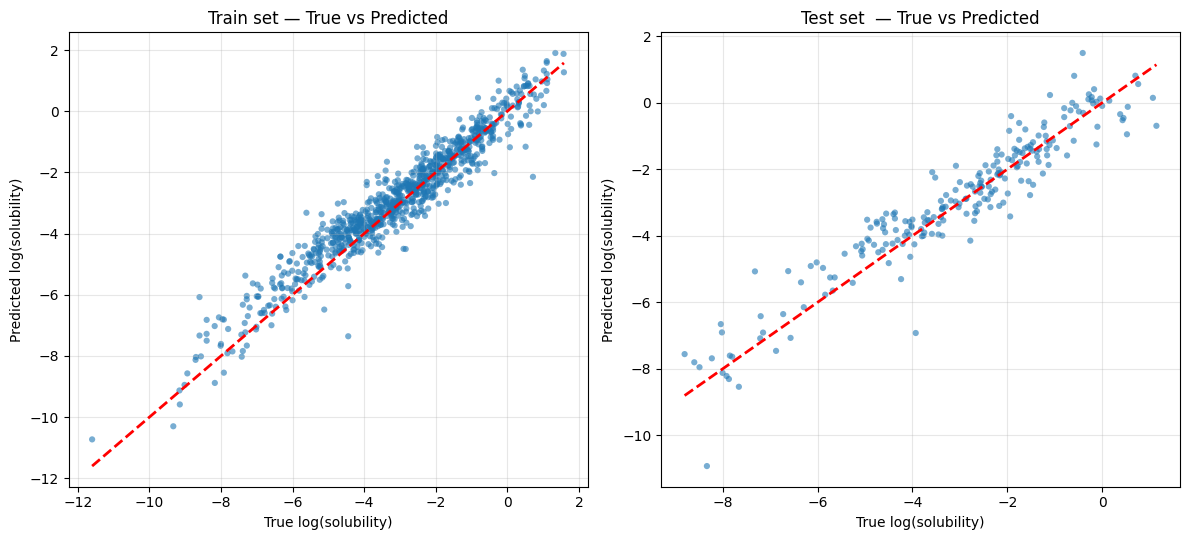

In [24]:
import matplotlib.pyplot as plt

def plot_true_vs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.6, s=20, edgecolor='none')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax.set_xlabel("True log(solubility)")
    ax.set_ylabel("Predicted log(solubility)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

plot_true_vs_pred(train_true, train_preds, "Train set — True vs Predicted", axes[0])
plot_true_vs_pred(test_true,  test_preds,  "Test set  — True vs Predicted", axes[1])

plt.tight_layout()
plt.show()

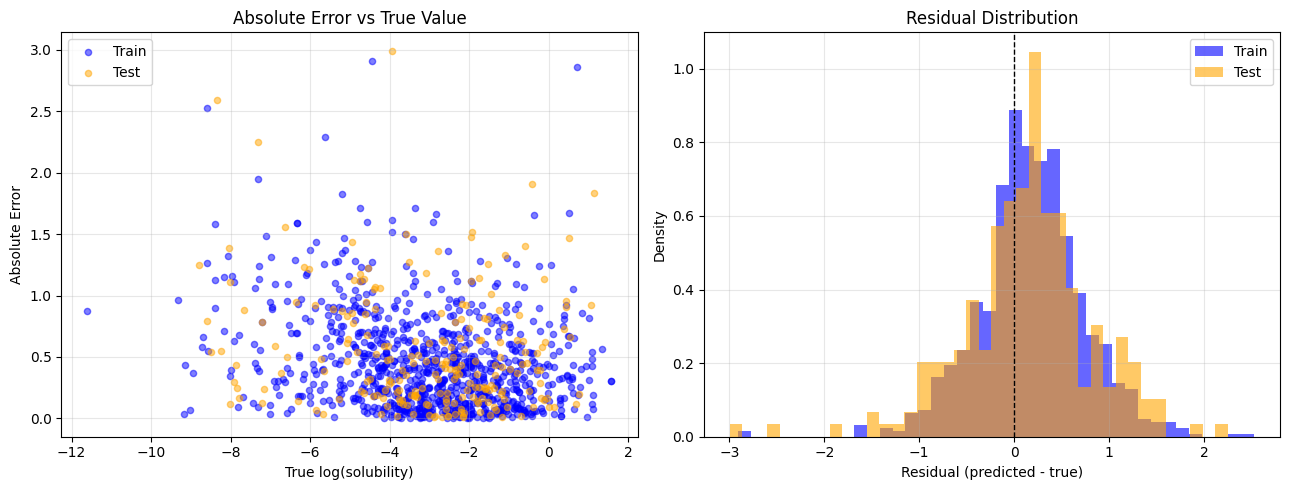

In [25]:
# Residual = predicted - true
train_res = train_preds - train_true
test_res  = test_preds  - test_true

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolute error vs true value
axes[0].scatter(train_true, np.abs(train_res), alpha=0.5, s=20, label='Train', c='blue')
axes[0].scatter(test_true,  np.abs(test_res),  alpha=0.5, s=20, label='Test',  c='orange')
axes[0].set_xlabel("True log(solubility)")
axes[0].set_ylabel("Absolute Error")
axes[0].set_title("Absolute Error vs True Value")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(train_res, bins=40, alpha=0.6, label='Train', color='blue', density=True)
axes[1].hist(test_res,  bins=40, alpha=0.6, label='Test',  color='orange', density=True)
axes[1].axvline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel("Residual (predicted - true)")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_add_pool

class GATMol(torch.nn.Module):
    def __init__(self, hidden_channels=128, heads=4):
        super().__init__()
        
        # First layer: more heads, concat = True → output dim = hidden * heads
        self.conv1 = GATConv(
            dataset.num_node_features,
            hidden_channels,
            heads=heads,
            concat=True,
            negative_slope=0.2,
            dropout=0.2,
            add_self_loops=True
        )
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels * heads)
        
        # Middle layer(s)
        self.conv2 = GATConv(
            hidden_channels * heads,
            hidden_channels,
            heads=heads,
            concat=True,
            negative_slope=0.2,
            dropout=0.2,
            add_self_loops=True
        )
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels * heads)
        
        # Last layer: usually reduce heads to 1 and concat=False
        self.conv3 = GATConv(
            hidden_channels * heads,
            hidden_channels,
            heads=1,
            concat=False,
            negative_slope=0.2,
            dropout=0.2,
            add_self_loops=True
        )
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels)
        
        # Final MLP: combine mean + sum pooling
        self.lin = torch.nn.Linear(hidden_channels * 2, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Layer 1
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)                  # ELU usually better than ReLU for GAT
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        # Layer 3
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        
        # Graph pooling: mean + add is often strong combination
        x_mean = global_mean_pool(x, batch)
        x_add  = global_add_pool(x, batch)
        x_cat  = torch.cat([x_mean, x_add], dim=-1)
        
        x = self.lin(x_cat)
        return x


# ────────────────────────────────────────────────
# Create model + optimizer + scheduler
# ────────────────────────────────────────────────

model = GATMol(hidden_channels=128, heads=4).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.003,                     # GAT often likes slightly lower starting LR
    weight_decay=1e-4
)

criterion = torch.nn.MSELoss()

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=12,
    verbose=True,
    min_lr=1e-6
)

print("GAT model created")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

GAT model created
Number of parameters: 338,305
Device: cuda


C:\Users\ghosh\Desktop\molgnn_env310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [27]:
# ────────────────────────────────────────────────
# Training settings
# ────────────────────────────────────────────────

patience = 40
best_test_rmse = float('inf')
best_epoch = 0
epochs_no_improve = 0
max_epochs = 350          # give it more room than before

print("Starting GAT training...\n")

for epoch in range(1, max_epochs + 1):
    model.train()
    total_loss = 0.0
    total_graphs = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)
        loss = criterion(out.squeeze(-1), batch.y.squeeze(-1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs
    
    train_loss = total_loss / total_graphs
    
    # Evaluate
    with torch.no_grad():
        train_rmse = evaluate(train_loader)
        test_rmse  = evaluate(test_loader)
    
    scheduler.step(test_rmse)
    
    if test_rmse < best_test_rmse:
        best_test_rmse = test_rmse
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_esol_gat.pt")
        print(f"  → New best Test RMSE: {test_rmse:.4f}  (epoch {epoch})")
    else:
        epochs_no_improve += 1
    
    # Print more frequently at beginning, then every 10
    if epoch <= 15 or epoch % 10 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | LR {lr_now:.1e} | loss {train_loss:7.4f} | "
              f"train RMSE {train_rmse:.4f} | test RMSE {test_rmse:.4f}")
    
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no improvement for {patience} epochs)")
        break

print("\n" + "═"*75)
print(f"Training finished")
print(f"Best test RMSE     : {best_test_rmse:.4f}   (epoch {best_epoch})")
print(f"Best model saved → best_esol_gat.pt")

Starting GAT training...

  → New best Test RMSE: 1.6131  (epoch 1)
Epoch   1 | LR 3.0e-03 | loss 17.3912 | train RMSE 1.5500 | test RMSE 1.6131
  → New best Test RMSE: 1.3797  (epoch 2)
Epoch   2 | LR 3.0e-03 | loss  2.0940 | train RMSE 1.2642 | test RMSE 1.3797
Epoch   3 | LR 3.0e-03 | loss  2.2355 | train RMSE 1.7101 | test RMSE 1.9286
  → New best Test RMSE: 1.3403  (epoch 4)
Epoch   4 | LR 3.0e-03 | loss  2.4999 | train RMSE 1.3271 | test RMSE 1.3403
  → New best Test RMSE: 1.2319  (epoch 5)
Epoch   5 | LR 3.0e-03 | loss  1.7925 | train RMSE 1.1244 | test RMSE 1.2319
Epoch   6 | LR 3.0e-03 | loss  1.7814 | train RMSE 1.6586 | test RMSE 1.7284
  → New best Test RMSE: 1.1351  (epoch 7)
Epoch   7 | LR 3.0e-03 | loss  1.7550 | train RMSE 1.0308 | test RMSE 1.1351
Epoch   8 | LR 3.0e-03 | loss  1.5093 | train RMSE 1.6365 | test RMSE 1.7277
Epoch   9 | LR 3.0e-03 | loss  1.4742 | train RMSE 1.3957 | test RMSE 1.5052
  → New best Test RMSE: 1.1242  (epoch 10)
Epoch  10 | LR 3.0e-03 | los

In [5]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO

# ────────────────────────────────────────────────
# Load your best model (the improved GCN version)
# ────────────────────────────────────────────────

model = BetterGCN(hidden_channels=128).to(device)  # must match your class name & hidden size
model.load_state_dict(torch.load("best_esol_improved_gcn.pt", map_location=device))
model.eval()

print("Best improved GCN model loaded successfully.")
print(f"Device: {device}")

Best improved GCN model loaded successfully.
Device: cuda


In [12]:
from torch_geometric.data import Data
import torch
from rdkit import Chem

def smiles_to_graph(smiles: str) -> Data:
    """
    Convert SMILES string to torch_geometric Data object using 
    the exact same 9-dimensional node features as MoleculeNet/ESOL.
    No explicit hydrogens are added.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")
    
    # Node features – exact match to ESOL dataset
    atom_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum(),                                           # 0
            1 if atom.GetChiralTag() != Chem.ChiralType.CHI_UNSPECIFIED else 0,  # 1
            atom.GetTotalDegree(),                                         # 2
            atom.GetFormalCharge(),                                        # 3
            atom.GetTotalNumHs(),                                          # 4
            atom.GetNumRadicalElectrons(),                                 # 5
            atom.GetHybridization().value if hasattr(atom.GetHybridization(), 'value') else 0,  # 6
            1 if atom.GetIsAromatic() else 0,                              # 7
            1 if atom.IsInRing() else 0                                    # 8
        ]
        atom_features.append(features)
    
    x = torch.tensor(atom_features, dtype=torch.float32)
    
    # Edge index (undirected graph)
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
    
    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    
    data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=mol.GetNumAtoms()
    )
    return data


@torch.no_grad()
def predict_solubility(smiles: str) -> float:
    try:
        data = smiles_to_graph(smiles)
        data = data.to(device)
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
        
        out = model(data)
        pred = out.item()
        return -float(pred)   # ← Flip the sign here!
    except Exception as e:
        return f"Error: {str(e)}"


# ────────────────────────────────────────────────
# Quick test with common molecules
# ────────────────────────────────────────────────
test_molecules = {
    "Ethanol":          "CCO",
    "Aspirin":          "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol":      "CC(=O)Nc1ccc(O)cc1",
    "Caffeine":         "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Benzene":          "c1ccccc1",
}

print("Testing inference with accurate featurization:\n")
for name, smi in test_molecules.items():
    pred = predict_solubility(smi)
    print(f"{name:12}  {smi:25}  →  {pred:.4f}")

Testing inference with accurate featurization:

Ethanol       CCO                        →  -0.2832
Aspirin       CC(=O)Oc1ccccc1C(=O)O      →  -2.3423
Paracetamol   CC(=O)Nc1ccc(O)cc1         →  -1.9995
Caffeine      CN1C=NC2=C1C(=O)N(C(=O)N2C)C  →  -3.0529
Benzene       c1ccccc1                   →  -1.0428


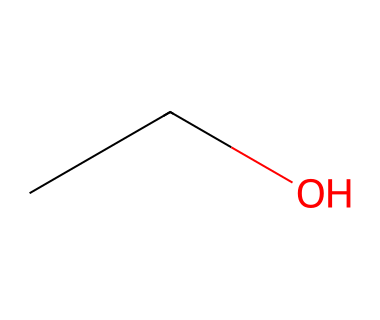

SMILES:   CCO
Predicted log(Solubility): -0.2832


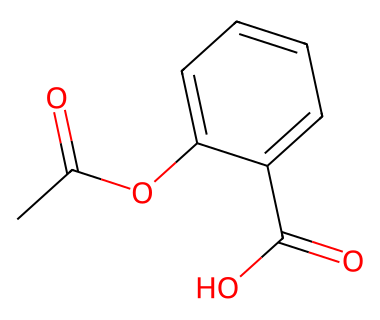

SMILES:   CC(=O)Oc1ccccc1C(=O)O
Predicted log(Solubility): -2.3423


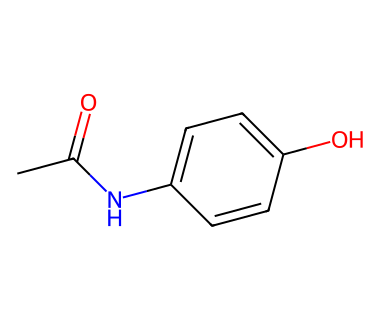

SMILES:   CC(=O)Nc1ccc(O)cc1
Predicted log(Solubility): -1.9995


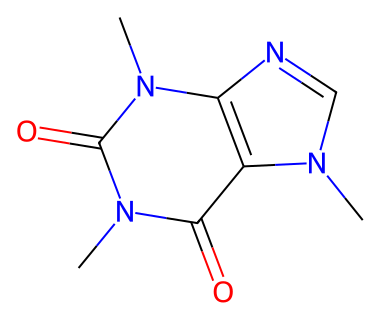

SMILES:   CN1C=NC2=C1C(=O)N(C(=O)N2C)C
Predicted log(Solubility): -3.0529


In [13]:
# Make sure these are imported (add at top if missing)
from IPython.display import display, SVG
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

def show_molecule_prediction(smiles: str):
    try:
        pred = predict_solubility(smiles)
        if isinstance(pred, str):  # error message returned
            print(pred)
            return
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print("Cannot parse SMILES")
            return
        
        AllChem.Compute2DCoords(mol)
        
        # SVG drawing (nicer in notebooks)
        drawer = Draw.MolDraw2DSVG(380, 320)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        svg_text = drawer.GetDrawingText()
        
        display(SVG(svg_text))
        
        print(f"SMILES:   {smiles}")
        print(f"Predicted log(Solubility): {pred:.4f}")
        
    except Exception as e:
        print("Error during visualization / prediction:", str(e))


# ─── Examples ────────────────────────────────────────────────────────────────

show_molecule_prediction("CCO")                              # Ethanol
show_molecule_prediction("CC(=O)Oc1ccccc1C(=O)O")          # Aspirin
show_molecule_prediction("CC(=O)Nc1ccc(O)cc1")             # Paracetamol / Acetaminophen
show_molecule_prediction("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")   # Caffeine

In [1]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn.functional as F
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from io import BytesIO
import base64

# ─── Required torch_geometric imports ───
from torch_geometric.nn import GCNConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data

# ────────────────────────────────────────────────
# Model definition
# ────────────────────────────────────────────────
class BetterGCN(torch.nn.Module):
    def __init__(self, hidden_channels=128):
        super().__init__()
        self.conv1 = GCNConv(9, hidden_channels)
        self.bn1   = torch.nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2   = torch.nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3   = torch.nn.BatchNorm1d(hidden_channels)
        self.lin   = torch.nn.Linear(hidden_channels * 2, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        
        x_mean = global_mean_pool(x, batch)
        x_sum  = global_add_pool(x, batch)
        x_cat  = torch.cat([x_mean, x_sum], dim=-1)
        return self.lin(x_cat)

# ────────────────────────────────────────────────
# Load model (cached)
# ────────────────────────────────────────────────
@st.cache_resource
def load_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = BetterGCN(128).to(device)
    try:
        model.load_state_dict(torch.load("best_esol_improved_gcn.pt", map_location=device))
        model.eval()
        st.success("Model loaded successfully!")
    except Exception as e:
        st.error(f"Model loading failed: {str(e)}\nMake sure 'best_esol_improved_gcn.pt' exists in the same folder as app.py")
    return model, device

model, device = load_model()

# ────────────────────────────────────────────────
# SMILES → Graph (same as notebook)
# ────────────────────────────────────────────────
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    atom_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum(),
            1 if atom.GetChiralTag() != Chem.ChiralType.CHI_UNSPECIFIED else 0,
            atom.GetTotalDegree(),               # ← changed
            atom.GetFormalCharge(),
            atom.GetNumImplicitHs(),             # ← usually correct for ESOL
            atom.GetNumRadicalElectrons(),
            atom.GetHybridization().value if hasattr(atom.GetHybridization(), 'value') else 0,
            1 if atom.GetIsAromatic() else 0,
            1 if atom.IsInRing() else 0
        ]
        atom_features.append(features)
    
    x = torch.tensor(atom_features, dtype=torch.float32)
    
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.extend([[i, j], [j, i]])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.empty((2, 0), dtype=torch.long)
    
    data = Data(x=x, edge_index=edge_index, num_nodes=mol.GetNumAtoms())
    return data

# ────────────────────────────────────────────────
# Prediction (with sign flip — adjust if needed)
# ────────────────────────────────────────────────
@torch.no_grad()
def predict_solubility(smiles):
    data = smiles_to_graph(smiles)
    if data is None:
        return None
    
    data = data.to(device)
    data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)
    
    out = model(data)
    pred = out.item()
    
    # If your model predicts -logS instead of logS → flip sign
    # Comment out the next line if predictions already look correct (negative for poorly soluble compounds)
    pred = -pred
    
    return float(pred)

# ────────────────────────────────────────────────
# Streamlit UI
# ────────────────────────────────────────────────
st.title("ESOL Solubility Prediction (GCN)")

smiles_input = st.text_input(
    "Enter SMILES string",
    value="CCO",
    help="Examples:\n• CCO (Ethanol)\n• CC(=O)Oc1ccccc1C(=O)O (Aspirin)\n• CC(=O)Nc1ccc(O)cc1 (Paracetamol)"
)

if st.button("Predict") or smiles_input.strip():
    with st.spinner("Processing molecule..."):
        pred = predict_solubility(smiles_input)
        
        if pred is None:
            st.error("Invalid SMILES string — please check syntax")
        else:
            try:
                mol = Chem.MolFromSmiles(smiles_input)
                AllChem.Compute2DCoords(mol)
                img = Draw.MolToImage(mol, size=(500, 400))
                
                buf = BytesIO()
                img.save(buf, format="PNG")
                byte_im = buf.getvalue()
                
                st.image(byte_im, caption=f"**Predicted log(Solubility): {pred:.4f}**", use_column_width=False)
                st.markdown(f"**Input SMILES:** `{smiles_input}`")
                
                # Optional: interpretation hint
                if pred > -0.5:
                    st.info("Near zero or positive → highly soluble (small polar molecules)")
                elif pred < -2.0:
                    st.info("Strongly negative → low solubility (typical for larger organics/drugs)")
                else:
                    st.info("Moderately soluble")
            except Exception as img_err:
                st.warning(f"Could not generate molecule image: {str(img_err)}")
                st.write(f"Prediction: **{pred:.4f}**")

Overwriting app.py
